In [1]:
import numpy as np

a, b, f0 = 158, 2, 40

def f(x):
    x1, x2 = x
    return a*(x1**2 - x2)**2 + b*(x1 - 1)**2 + f0

def grad(x):
    x1, x2 = x
    df_dx1 = 4*a*x1*(x1**2 - x2) + 2*b*(x1 - 1)
    df_dx2 = -2*a*(x1**2 - x2)
    return np.array([df_dx1, df_dx2])

## Сопряженные градиенты (Fletcher-Reeves)


In [2]:
def conjugate_gradient_fr(x0, tol=1e-6, max_iter=1000):
    x = x0.copy()
    g = grad(x)
    d = -g

    for k in range(max_iter):
        alpha = line_search(x, d)
        x_new = x + alpha * d
        g_new = grad(x_new)

        if np.linalg.norm(g_new) < tol:
            break

        beta = np.dot(g_new, g_new) / np.dot(g, g)
        d = -g_new + beta * d

        x, g = x_new, g_new

    return x

### Polak-Ribiere

In [3]:
def conjugate_gradient_pr(x0, tol=1e-6, max_iter=1000):
    x = x0.copy()
    g = grad(x)
    d = -g

    for k in range(max_iter):
        alpha = line_search(x, d)
        x_new = x + alpha * d
        g_new = grad(x_new)

        if np.linalg.norm(g_new) < tol:
            break

        beta = np.dot(g_new, g_new - g) / np.dot(g, g)
        d = -g_new + beta * d

        x, g = x_new, g_new

    return x

### Квазиньютоновские методы (BFGS)

In [4]:
def bfgs(x0, tol=1e-6, max_iter=1000):
    x = x0.copy()
    n = len(x)
    H = np.eye(n)

    for _ in range(max_iter):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break

        d = -H @ g
        alpha = line_search(x, d)

        s = alpha * d
        x_new = x + s
        y = grad(x_new) - g

        rho = 1.0 / (y @ s)
        I = np.eye(n)

        H = (I - rho * np.outer(s, y)) @ H @ (I - rho * np.outer(y, s)) + rho * np.outer(s, s)

        x = x_new

    return x

### DFP

In [5]:
def dfp(x0, tol=1e-6, max_iter=1000):
    x = x0.copy()
    n = len(x)
    H = np.eye(n)

    for _ in range(max_iter):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break

        d = -H @ g
        alpha = line_search(x, d)

        s = alpha * d
        x_new = x + s
        y = grad(x_new) - g

        H += np.outer(s, s)/(s@y) - (H @ np.outer(y, y) @ H)/(y @ H @ y)

        x = x_new

    return x

### L-BFGS

In [6]:
from scipy.optimize import minimize

res = minimize(f, x0=[-1, 2], method='L-BFGS-B', jac=grad)
print(res.x)

[1.00000011 1.00000001]


### Line-Search

In [7]:
def line_search(x, d, alpha=1.0, rho=0.5, c=1e-4):
    while f(x + alpha*d) > f(x) + c*alpha*np.dot(grad(x), d):
        alpha *= rho
    return alpha

### Execution Time Estimation

In [8]:
import time

def test(method, x0):
    start = time.time()
    x = method(x0)
    t = time.time() - start
    return x, f(x), t

## Результаты

In [9]:
import pandas as pd

# начальная точка (типично для Розенброка)
x0 = np.array([-1.2, 1.0])

# --- обёртки для подсчёта итераций ---

def run_with_stats(method, name):
    history = []

    def wrapped_method(x0):
        x = x0.copy()
        g = grad(x)
        d = -g

        start = time.time()
        iters = 0

        # разные методы имеют разную логику → проверяем по имени
        if name in ["FR", "PR"]:
            for _ in range(1000):
                alpha = line_search(x, d)
                x_new = x + alpha * d
                g_new = grad(x_new)

                history.append(np.linalg.norm(g_new))
                iters += 1

                if np.linalg.norm(g_new) < 1e-6:
                    break

                if name == "FR":
                    beta = np.dot(g_new, g_new) / np.dot(g, g)
                else:  # PR
                    beta = np.dot(g_new, g_new - g) / np.dot(g, g)

                d = -g_new + beta * d
                x, g = x_new, g_new

        elif name in ["BFGS", "DFP"]:
            n = len(x)
            H = np.eye(n)

            for _ in range(1000):
                g = grad(x)
                history.append(np.linalg.norm(g))
                iters += 1

                if np.linalg.norm(g) < 1e-6:
                    break

                d = -H @ g
                alpha = line_search(x, d)

                s = alpha * d
                x_new = x + s
                y = grad(x_new) - g

                if name == "BFGS":
                    rho = 1.0 / (y @ s)
                    I = np.eye(n)
                    H = (I - rho * np.outer(s, y)) @ H @ (I - rho * np.outer(y, s)) + rho * np.outer(s, s)
                else:  # DFP
                    H += np.outer(s, s)/(s@y) - (H @ np.outer(y, y) @ H)/(y @ H @ y)

                x = x_new

        elapsed = time.time() - start
        return x, f(x), iters, elapsed, history

    return wrapped_method(x0)


# --- запуск всех методов ---

results = []

methods = [
    ("Fletcher-Reeves", "FR"),
    ("Polak-Ribiere", "PR"),
    ("BFGS", "BFGS"),
    ("DFP", "DFP"),
]

for name_full, name_short in methods:
    x_min, f_min, iters, t, history = run_with_stats(None, name_short)

    results.append({
        "Метод": name_full,
        "x": x_min,
        "f(x)": f_min,
        "Итерации": iters,
        "Время (сек)": t
    })

# L-BFGS отдельно через scipy
from scipy.optimize import minimize

start = time.time()
res = minimize(f, x0, method='L-BFGS-B', jac=grad)
elapsed = time.time() - start

results.append({
    "Метод": "L-BFGS",
    "x": res.x,
    "f(x)": res.fun,
    "Итерации": res.nit,
    "Время (сек)": elapsed
})

# --- вывод таблицы ---
df = pd.DataFrame(results)
print(df)

             Метод                                         x  f(x)  Итерации  \
0  Fletcher-Reeves   [1.000000037633409, 1.0000000606340727]  40.0        68   
1    Polak-Ribiere  [1.0000000888378342, 1.0000001805469871]  40.0       139   
2             BFGS  [1.0000000001097906, 1.0000000002605771]  40.0        20   
3              DFP  [1.0000000344212259, 1.0000000693324473]  40.0       910   
4           L-BFGS  [0.9999999563490786, 0.9999999276403196]  40.0        35   

   Время (сек)  
0     0.007428  
1     0.024617  
2     0.001389  
3     0.148387  
4     0.014062  


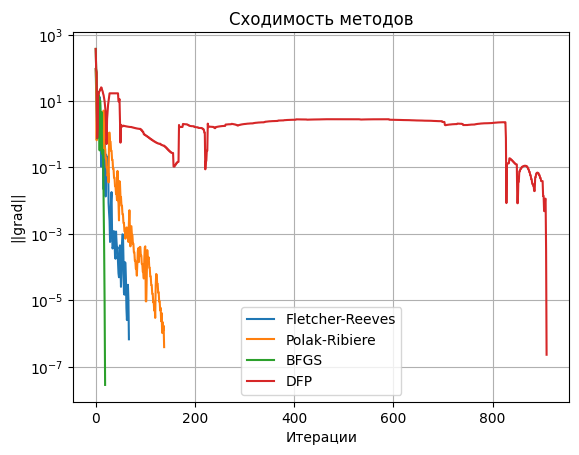

In [10]:
import matplotlib.pyplot as plt

for name_full, name_short in methods:
    _, _, _, _, history = run_with_stats(None, name_short)
    plt.plot(history, label=name_full)

plt.yscale("log")
plt.xlabel("Итерации")
plt.ylabel("||grad||")
plt.title("Сходимость методов")
plt.legend()
plt.grid()
plt.show()